In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv('laptop.csv')

In [3]:
data

,Company,TypeName,Ram,OpSys,Weight,Touchscreen,CpuCompany,ClockSpeed,Flash Storage,HDD,Hybrid,SSD,GPU,Ppi,Price
0,Apple,Ultrabook,8,macOS,1.37,0,Intel,2.3,0.000,0.0,0.0,0.128,Intel,312.781955,71378.6832
1,Apple,Ultrabook,8,macOS,1.34,0,Intel,1.8,0.128,0.0,0.0,0.000,Intel,175.939850,47895.5232
2,HP,Notebook,8,No,1.86,0,Intel,2.5,0.000,0.0,0.0,0.256,Intel,192.307692,30636.0000
3,Apple,Ultrabook,16,macOS,1.83,0,Intel,2.7,0.000,0.0,0.0,0.512,AMD,303.896104,135195.3360
4,Apple,Ultrabook,8,macOS,1.37,0,Intel,3.1,0.000,0.0,0.0,0.256,Intel,312.781955,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,Windows,1.80,1,Intel,2.5,0.000,0.0,0.0,0.128,Intel,214.285714,33992.6400
1299,Lenovo,2 in 1 Convertible,16,Windows,1.30,1,Intel,2.5,0.000,0.0,0.0,0.512,Intel,375.939850,79866.7200
1300,Lenovo,Notebook,2,Windows,1.50,0,Intel,1.6,0.064,0.0,0.0,0.000,Intel,152.428571,12201.1200
1301,HP,Notebook,6,Windows,2.19,0,Intel,2.5,0.000,1.0,0.0,0.000,AMD,136.794872,40705.9200


In [4]:
print(data.head())
print(data.shape)
print(data.columns)

  Company   TypeName  Ram  OpSys  Weight  Touchscreen CpuCompany  ClockSpeed  \
0   Apple  Ultrabook    8  macOS    1.37            0      Intel         2.3   
1   Apple  Ultrabook    8  macOS    1.34            0      Intel         1.8   
2      HP   Notebook    8     No    1.86            0      Intel         2.5   
3   Apple  Ultrabook   16  macOS    1.83            0      Intel         2.7   
4   Apple  Ultrabook    8  macOS    1.37            0      Intel         3.1   

   Flash Storage  HDD  Hybrid    SSD    GPU         Ppi        Price  
0          0.000  0.0     0.0  0.128  Intel  312.781955   71378.6832  
1          0.128  0.0     0.0  0.000  Intel  175.939850   47895.5232  
2          0.000  0.0     0.0  0.256  Intel  192.307692   30636.0000  
3          0.000  0.0     0.0  0.512    AMD  303.896104  135195.3360  
4          0.000  0.0     0.0  0.256  Intel  312.781955   96095.8080  
(1303, 15)
Index(['Company', 'TypeName', 'Ram', 'OpSys', 'Weight', 'Touchscreen',
       'Cpu

In [5]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1303 non-null   object 
 1   TypeName       1303 non-null   object 
 2   Ram            1303 non-null   int64  
 3   OpSys          1303 non-null   object 
 4   Weight         1303 non-null   float64
 5   Touchscreen    1303 non-null   int64  
 6   CpuCompany     1303 non-null   object 
 7   ClockSpeed     1303 non-null   float64
 8   Flash Storage  1303 non-null   float64
 9   HDD            1303 non-null   float64
 10  Hybrid         1303 non-null   float64
 11  SSD            1303 non-null   float64
 12  GPU            1303 non-null   object 
 13  Ppi            1303 non-null   float64
 14  Price          1303 non-null   float64
dtypes: float64(8), int64(2), object(5)
memory usage: 152.8+ KB
None
               Ram       Weight  Touchscreen   ClockSpeed  Flash Storage  \


In [6]:
print(data.isnull().sum())

Company          0
TypeName         0
Ram              0
OpSys            0
Weight           0
Touchscreen      0
CpuCompany       0
ClockSpeed       0
Flash Storage    0
HDD              0
Hybrid           0
SSD              0
GPU              0
Ppi              0
Price            0
dtype: int64


In [7]:
print(data[data.isnull().any(axis=1)])

Empty DataFrame
Columns: [Company, TypeName, Ram, OpSys, Weight, Touchscreen, CpuCompany, ClockSpeed, Flash Storage, HDD, Hybrid, SSD, GPU, Ppi, Price]
Index: []


In [8]:
data = data.dropna()

In [9]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 30


In [10]:
data = data.drop_duplicates()

In [11]:
print("Average Price:", data["Price"].mean())

Average Price: 60500.69770934799


In [12]:
print("Minimum Price:", data["Price"].min())

Minimum Price: 9270.72


In [13]:
print("Maximum Price:", data["Price"].max())

Maximum Price: 324954.72


In [14]:
company_price = data.groupby("Company")["Price"].mean().sort_values(ascending=False)

print(company_price)

Company
Razer        178282.491429
LG           111834.720000
MSI           92116.226133
Google        89386.080000
Microsoft     85903.788000
Apple         83340.499886
Huawei        75870.720000
Samsung       75308.320000
Toshiba       67631.591489
Dell          63894.714408
Xiaomi        60390.882000
Asus          60143.988302
Lenovo        58280.978790
HP            57559.165307
Fujitsu       38841.120000
Acer          33750.986186
Chuwi         16745.726400
Mediacom      15717.600000
Vero          11584.404000
Name: Price, dtype: float64


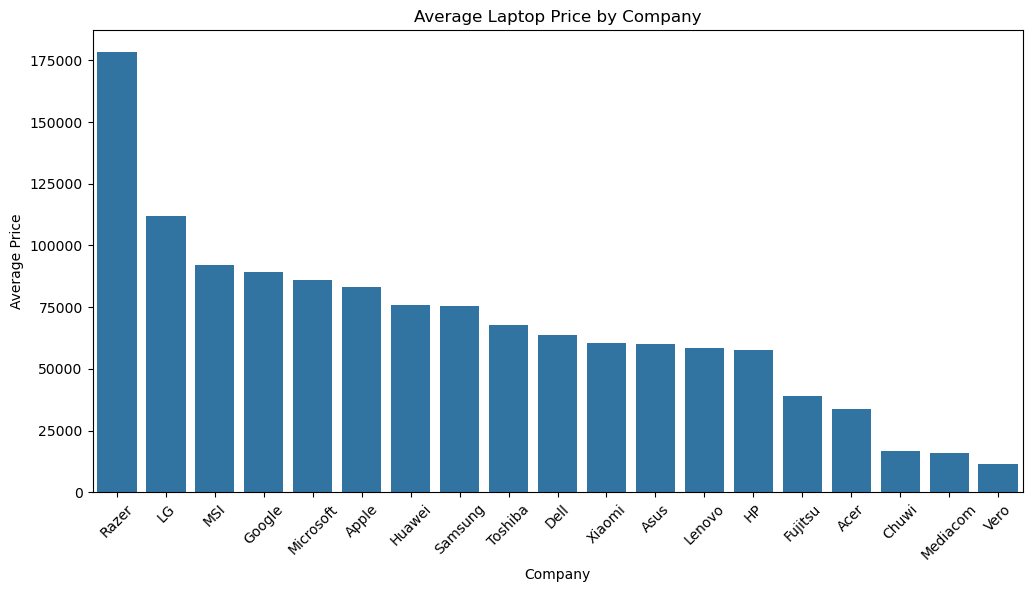

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=company_price.index,
    y=company_price.values
)

plt.xticks(rotation=45)
plt.title("Average Laptop Price by Company")
plt.xlabel("Company")
plt.ylabel("Average Price")
plt.show()

In [16]:
ram_price = data.groupby("Ram")["Price"].mean()

print(ram_price)

Ram
2      13193.959500
4      30634.984031
6      32999.318126
8      63106.399110
12     66037.277952
16    103426.767345
24    117553.440000
32    181849.215812
64    211788.000000
Name: Price, dtype: float64


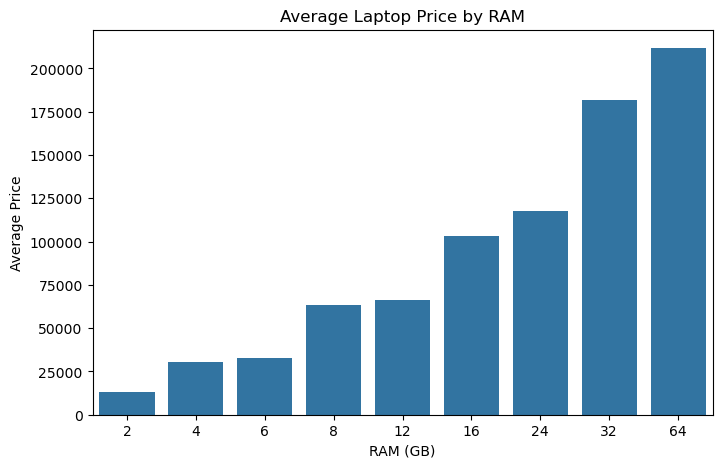

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=ram_price.index,
    y=ram_price.values
)

plt.title("Average Laptop Price by RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price")
plt.show()

In [18]:
type_price = data.groupby("TypeName")["Price"].mean().sort_values(ascending=False)

print(type_price)

TypeName
Workstation           121497.525683
Gaming                 92247.960187
Ultrabook              82939.698928
2 in 1 Convertible     68715.990154
Notebook               42025.341386
Netbook                35877.825391
Name: Price, dtype: float64


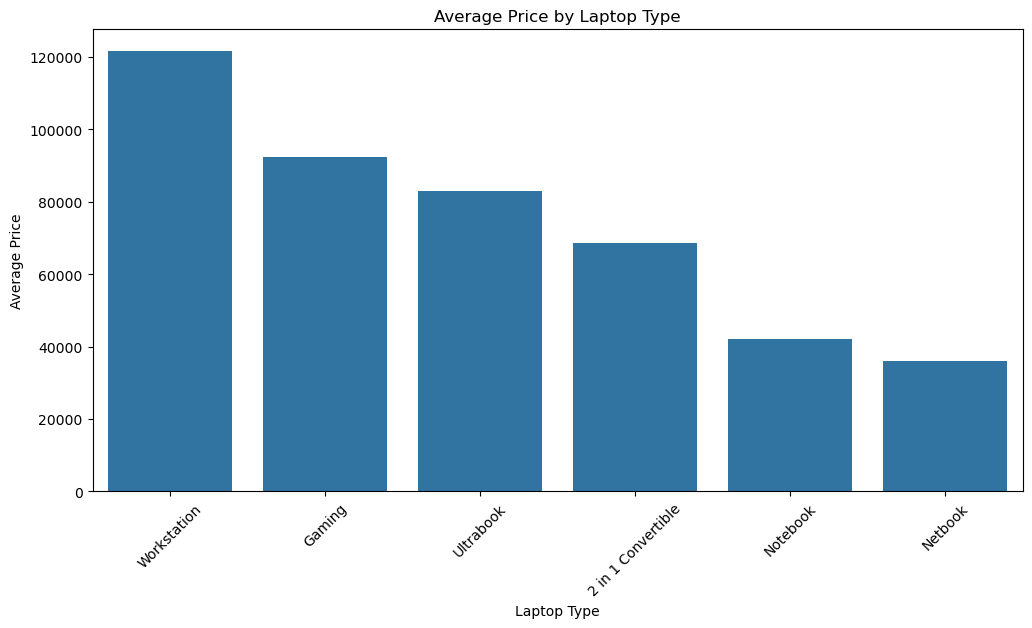

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=type_price.index,
    y=type_price.values
)

plt.xticks(rotation=45)
plt.title("Average Price by Laptop Type")
plt.xlabel("Laptop Type")
plt.ylabel("Average Price")
plt.show()

In [20]:
cpu_price = data.groupby("CpuCompany")["Price"].mean()

print(cpu_price)

CpuCompany
AMD        29889.751440
Intel      62037.039255
Samsung    35111.520000
Name: Price, dtype: float64


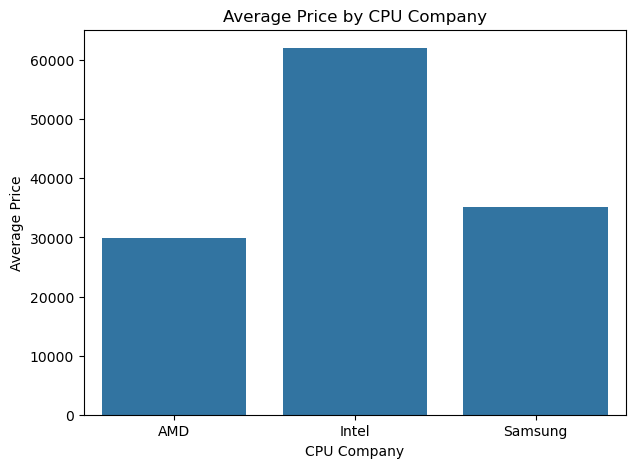

In [21]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=cpu_price.index,
    y=cpu_price.values
)

plt.title("Average Price by CPU Company")
plt.xlabel("CPU Company")
plt.ylabel("Average Price")
plt.show()

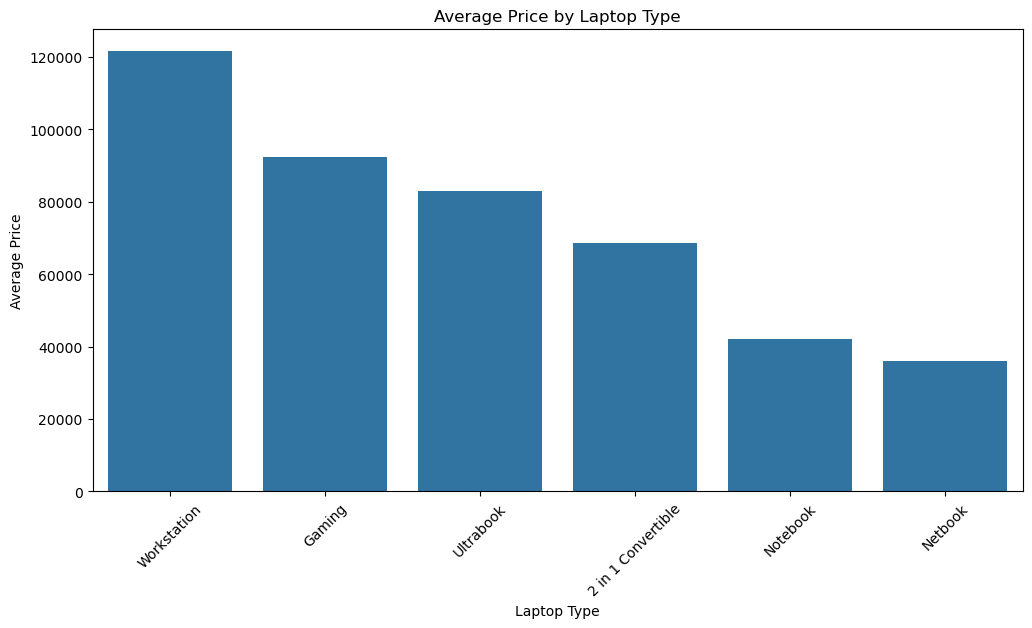

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=type_price.index,
    y=type_price.values
)

plt.xticks(rotation=45)
plt.title("Average Price by Laptop Type")
plt.xlabel("Laptop Type")
plt.ylabel("Average Price")
plt.show()

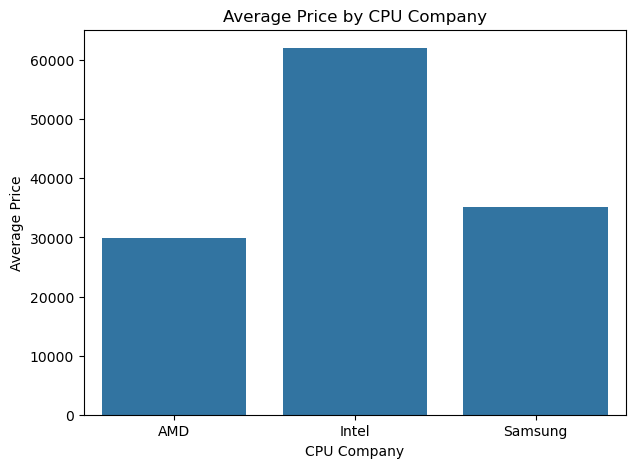

In [23]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=cpu_price.index,
    y=cpu_price.values
)

plt.title("Average Price by CPU Company")
plt.xlabel("CPU Company")
plt.ylabel("Average Price")
plt.show()

In [24]:
gpu_price = data.groupby("GPU")["Price"].mean().sort_values(ascending=False)

print(gpu_price)

GPU
Nvidia    79746.578982
Intel     54401.374749
AMD       41453.254676
ARM       35111.520000
Name: Price, dtype: float64


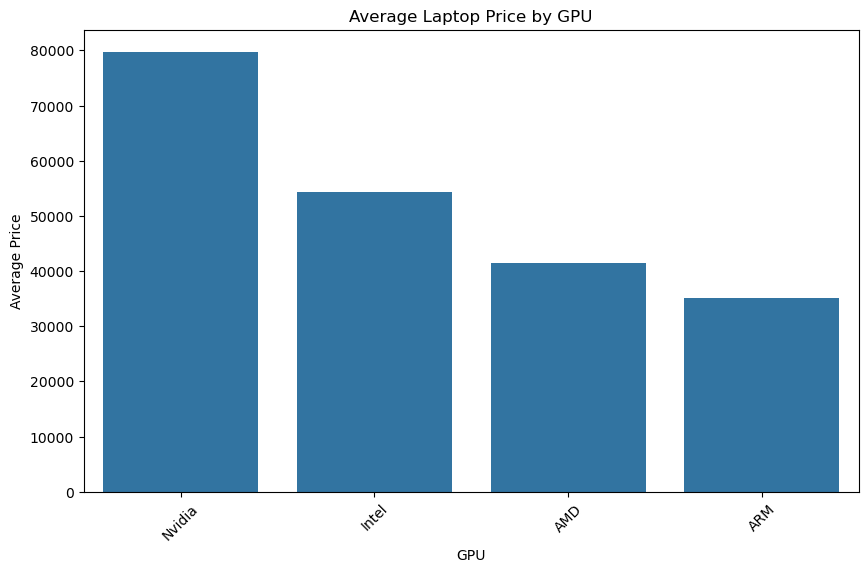

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=gpu_price.index,
    y=gpu_price.values
)

plt.xticks(rotation=45)
plt.title("Average Laptop Price by GPU")
plt.xlabel("GPU")
plt.ylabel("Average Price")
plt.show()

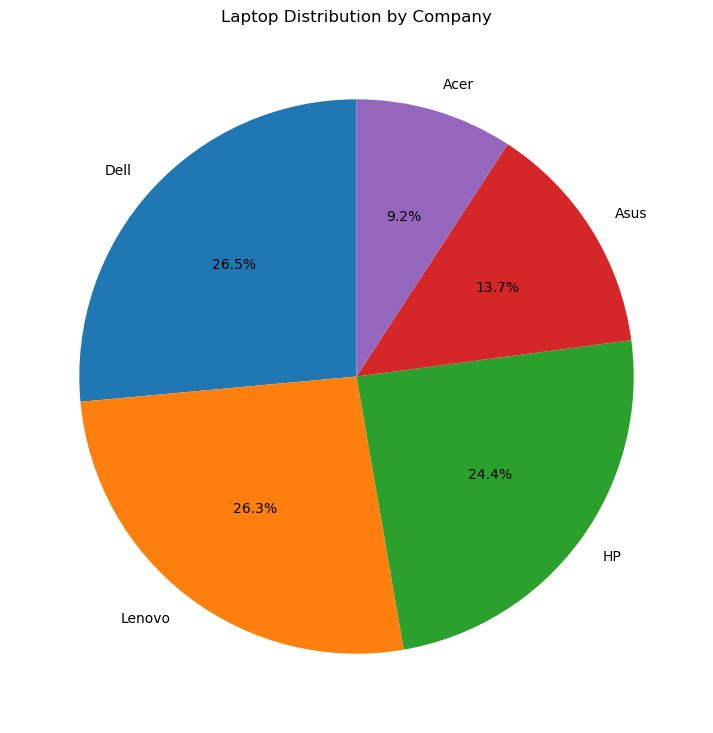

In [26]:
company_count = data["Company"].value_counts().head(5)

plt.figure(figsize=(9, 9))

plt.pie(
    company_count.values,
    labels=company_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Laptop Distribution by Company")
plt.show()

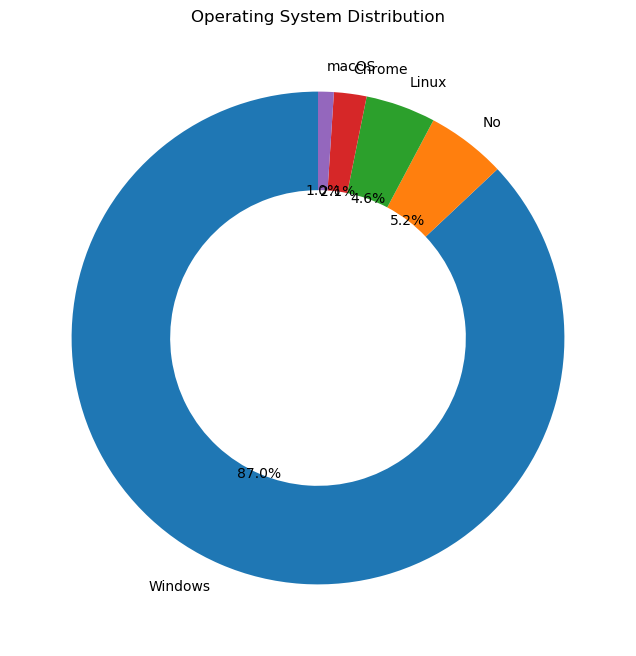

In [27]:
os_count = data["OpSys"].value_counts().head(5)

plt.figure(figsize=(8, 8))

plt.pie(
    os_count.values,
    labels=os_count.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Operating System Distribution")
plt.show()

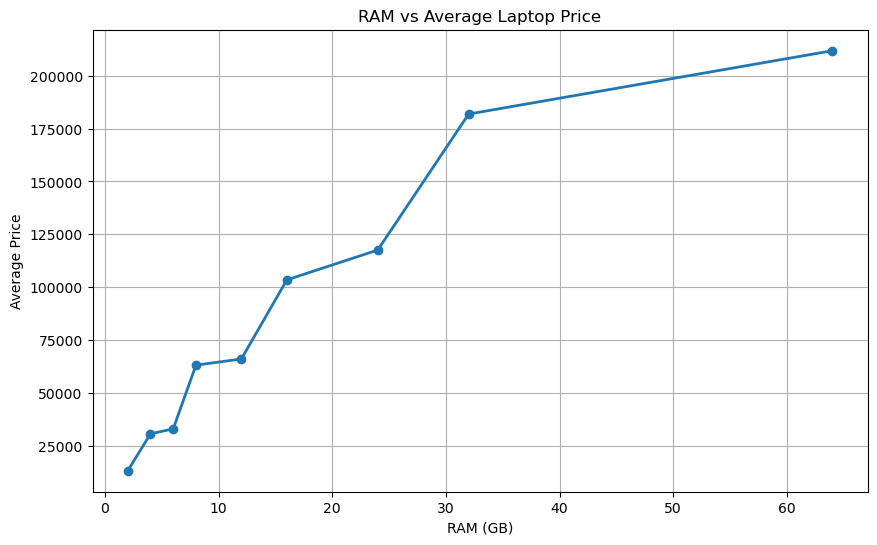

In [28]:
ram_price = data.groupby("Ram")["Price"].mean().sort_index()

plt.figure(figsize=(10, 6))

plt.plot(
    ram_price.index,
    ram_price.values,
    marker="o",
    linewidth=2
)

plt.title("RAM vs Average Laptop Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price")
plt.grid(True)

plt.show()

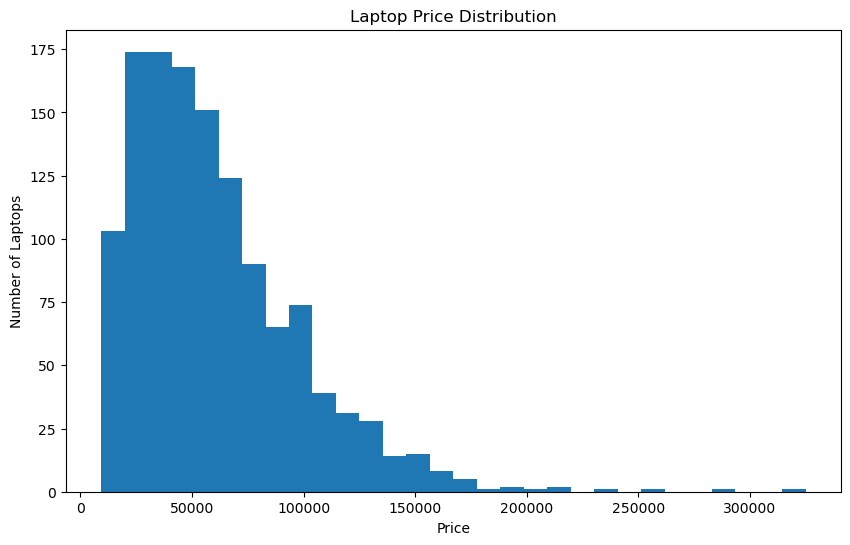

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(
    data["Price"],
    bins=30
)

plt.title("Laptop Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Laptops")

plt.show()

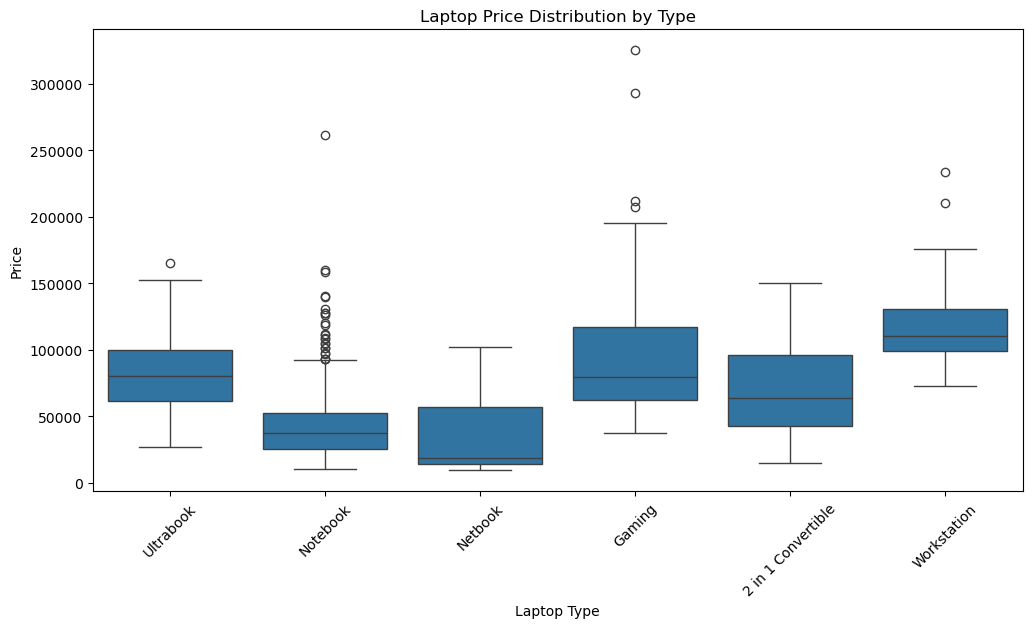

In [30]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=data,
    x="TypeName",
    y="Price"
)

plt.title("Laptop Price Distribution by Type")
plt.xlabel("Laptop Type")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.show()

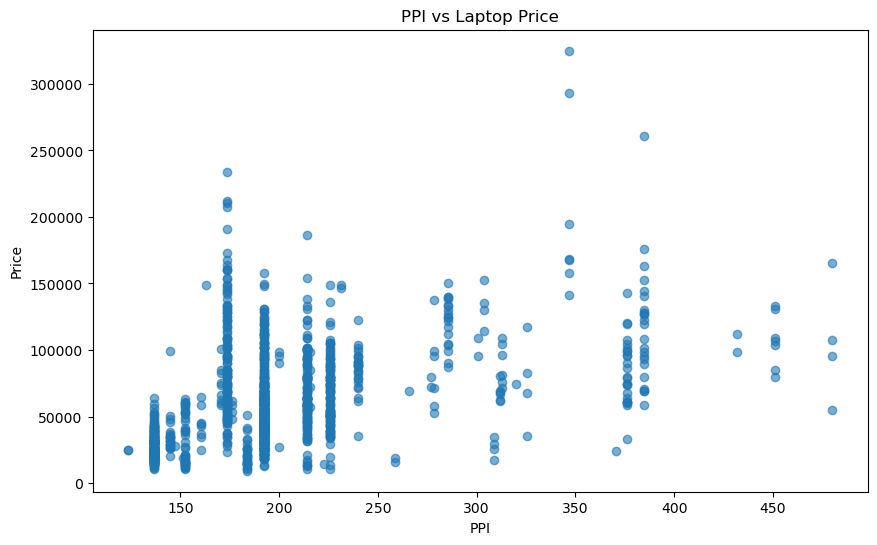

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(
    data["Ppi"],
    data["Price"],
    alpha=0.6
)

plt.title("PPI vs Laptop Price")
plt.xlabel("PPI")
plt.ylabel("Price")

plt.show()

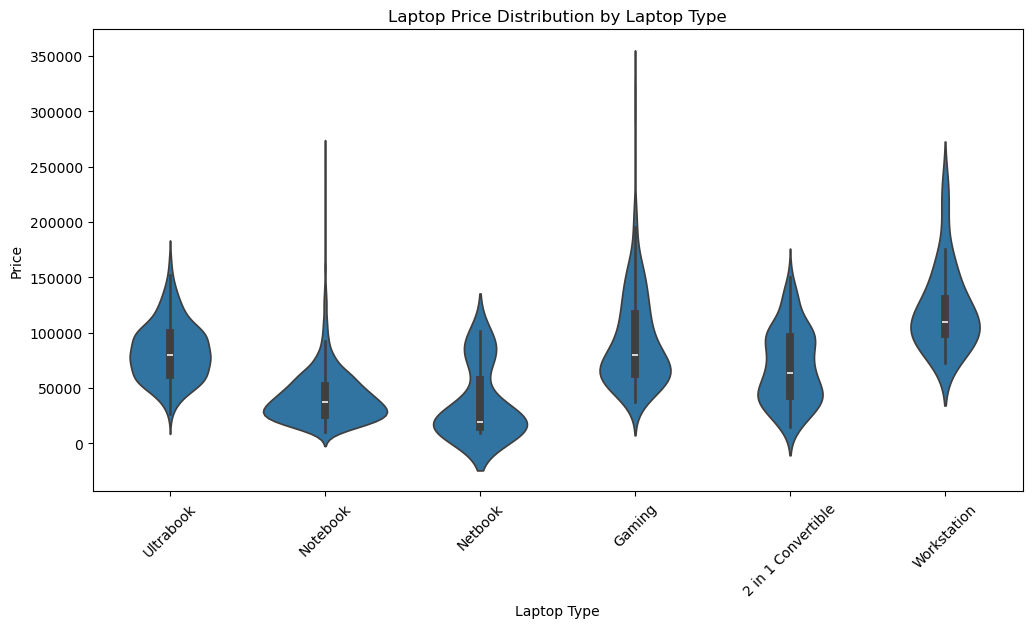

In [32]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=data,
    x="TypeName",
    y="Price"
)

plt.title("Laptop Price Distribution by Laptop Type")
plt.xlabel("Laptop Type")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.show()

<Axes: >

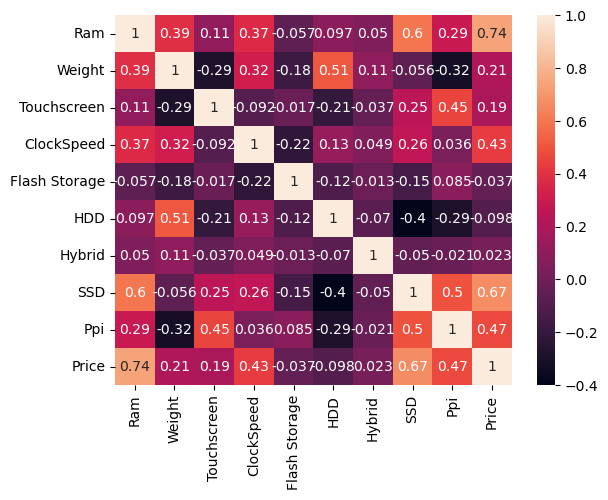

In [33]:
correlation = data.corr(numeric_only=True)
sns.heatmap(correlation, annot=True)